# Problem Set 1


#Hodgkin Huxley Simulation & Action Potential Concepts


## Differential equations background

At the most basic level, a differential equation relates the value of a function to its derivatives. In sciences that deal with complex dynamical systems (e.g. neuroscience), they are a convenient tool to describe the behaviour of a system in terms of how its constituent parts change over time -- it is often easier to specify a series of time-derivatives than to write down an equation that immediately gives the state of the system at any given time.

For concreteness, let's say you have some function $f(t)$. A differential equation looks something like $\frac{df(t)}{dt} = g(f(t))$, where the derivative of a function is related to the function itself through another function $g$. One fundamental example is $\frac{df(t)}{dt} = f(t)$ (the derivative of $f$ is equal to $f$). When we have a differential equation such as this, we often would like to find its **solution**; the solution to a differential equation is the value of $f(t)$ for a set of times that we might be interested in.

This can be provided in two ways. For some differential equations there exists an analytical solution -- i.e. it is possible to derive a closed-form expression for $f(t)$ that doesn't depend on any derivatives. The differential equation example from the previous paragraph, for instance, admits an analytical solution $f(t) = e^t$. These are ideal, because we can just plug in whatever value of $t$ we care about without doing any additional work. Some differential equations, however, don't have an analytical solution.

For these, we have to engage in a process called "numerical integration". Essentially, this means that we will approximate the value of $f(t)$ by some numerical process. The most simple example of this is Euler's method. In general, it comes down to the following equation:

$$
    f(t + \Delta t) \approx f(t) + \Delta t \frac{df(t)}{dt}
$$

In English: if you know $f(t)$ for a particular $t$, and you know the time-derivative of that function also at that $t$, then you can approximate the value of the function a short time later $f(t + \Delta t)$ as $f(t) + \Delta t \frac{df(t)}{dt}$. This means that if you have an initial value for your function (e.g. you know that $f(0) = 1$), and if you have a way of computing derivatives for your function (e.g. you have an expression for $\frac{df(t)}{dt}$) then you can approximate the value of that function at any other time.

In practice, these simulations work best if $\Delta t$ is very small (and in fact work better the smaller $\Delta t$ is). So if you want to know the value of your function $f$ at a time $t'$ that is very far away from the time you know $f(0)$, you might choose a very small $\Delta t << t'$ and iteratively compute $f(\Delta t), f(2 \Delta t), ..., f(t' - \Delta t), f(t')$ to maintain accuracy.

This $\Delta t$ is often known as a time-step.

## Simulating a Hodgkin-Huxley neuron

The Hodgkin-Huxley model consists of four differential equations that together define a dynamical system. This dynamical system computes the voltage of a space-clamped membrane as a function of time $t$ and three other variables $n, m,$ and $h$. These equations are:

$$
    \frac{dV}{dt} = \frac{I - \bar{g}_{Na}m^3h(V - V_{Na}) - \bar{g}_Kn^4(V - V_K) - g_L(V - V_L)}{C} \\
    \frac{dn}{dt} = \alpha_n(V)(1 - n) - \beta_n(V)n \\
    \frac{dm}{dt} = \alpha_m(V)(1 - m) - \beta_m(V)m \\
    \frac{dh}{dt} = \alpha_h(V)(1 - h) - \beta_h(V)h
$$

where

$$
    \alpha_n(V) = \frac{0.01(V + 55)}{1 - exp[-\frac{1}{10}(V + 55)]} \quad \quad \quad \beta_n(V) = 0.125 \cdot exp[-\frac{1}{80}(V + 65)] \\
    \alpha_m(V) = \frac{0.1(V + 40)}{1 - exp[-\frac{1}{10}(V + 40)]} \quad \quad \quad \beta_m(V) = 4 \cdot exp[-\frac{1}{18}(V + 65)] \\
    \alpha_h(V) = 0.07 \cdot exp[-\frac{1}{20}(V + 65)] \quad \quad \quad \beta_h(V) = \frac{1}{1 + exp[-\frac{1}{10}(V + 35)]}
$$

As described in lecture, $V$ is the transmembrane potential, $I$ is the current injected into the neuron from a microelectrode, and $n, m,$ and $h$ are dimensionless gating variables. In these equations, voltages are measured in $mV$, current density in $\mu A/cm^2$, capacitance density in $\mu F/cm^2$, and time in $ms$. The values of the constants at $6.3^{\circ}C$ are:

$$
    \bar{g}_{Na} = 120 mmho/cm^2 \quad \quad \bar{g}_K = 36 mmho/cm^2 \quad \quad g_L = 0.3 mmho/cm^2 \\
    V_{Na} = 50 mV \quad \quad V_K = -77mV \quad \quad V_L = -54.4mV \quad \quad C = 1 \mu F/cm^2
$$

N.B. These equations are written using modern conventions and look a little different than they do in the original Hodgkin-Huxley (1952) paper. One obtains the equations in this paper by letting $V_{HH} = -V - 65$.

## HH Simulation Code:

Examine the provided HH simulation functions (Adapted from Mark Kramer and Uri Eden), and compare them to the equations above. Can you identify the gating variables? The rate functions? The equations that define the dynamics? Can you determine which of the gating variables correspond to which ion channel (Cl-, K+, Na+)? *Hint: you should be able to infer this from the voltage equation alone using what you know about channel dynamics.*

In [1]:
# libraries
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_context("talk")

In [84]:
#Activation functions for the gating particles:
def alphaM(V):
    return (2.5-0.1*(V+65)) / (np.exp(2.5-0.1*(V+65)) -1)

def betaM(V):
    return 4*np.exp(-(V+65)/18)

def alphaH(V):
    return 0.07*np.exp(-(V+65)/20)

#Deactivation functions for the gating particles:
def betaH(V):
    return 1/(np.exp(3.0-0.1*(V+65))+1)

def alphaN(V):
    return (0.1-0.01*(V+65)) / (np.exp(1-0.1*(V+65)) -1)

def betaN(V):
    return 0.125*np.exp(-(V+65)/80)

def HH(Ibase,T0,InjCurrent=False,Iinj=0,Istart=0,Iend=0, gK0=36):

    #Initializing parameters
    dt = 0.01;
    T  = math.ceil(T0/dt)  # [ms]
    Istart = math.ceil(Istart/dt) # [ms]
    Iend = math.ceil(Iend/dt) # [ms]

    #Constants for Eion and conductances
    gNa0 = 120   # [mS/cm^2]
    ENa  = 115;  # [mV]
    EK   = -12;  # [mV]
    gL0  = 0.3;  # [mS/cm^2]
    EL   = 10.6; # [mV]

    t = np.arange(0,T)*dt
    V = np.zeros([T,1])
    m = np.zeros([T,1])
    h = np.zeros([T,1])
    n = np.zeros([T,1])
    Itrace = np.zeros([T,1])

    # Store alpha/beta time series
    alpha_m = np.zeros([T,1])
    beta_m  = np.zeros([T,1])
    alpha_h = np.zeros([T,1])
    beta_h  = np.zeros([T,1])
    alpha_n = np.zeros([T,1])
    beta_n  = np.zeros([T,1])

    V[0]=-70.0
    m[0]=0.05
    h[0]=0.54
    n[0]=0.34

    for i in range(0,T-1):
        # Injected current
        if InjCurrent and Istart < i < Iend:
            I = Iinj
        else:
            I = Ibase

        alpha_m[i] = alphaM(V[i])
        beta_m[i]  = betaM(V[i])
        alpha_h[i] = alphaH(V[i])
        beta_h[i]  = betaH(V[i])
        alpha_n[i] = alphaN(V[i])
        beta_n[i]  = betaN(V[i])

        V[i+1] = V[i] + dt*(gNa0*m[i]**3*h[i]*(ENa-(V[i]+65)) + 
                            gK0*n[i]**4*(EK-(V[i]+65)) + 
                            gL0*(EL-(V[i]+65)) + I)
        m[i+1] = m[i] + dt*(alpha_m[i]*(1-m[i]) - beta_m[i]*m[i])
        h[i+1] = h[i] + dt*(alpha_h[i]*(1-h[i]) - beta_h[i]*h[i])
        n[i+1] = n[i] + dt*(alpha_n[i]*(1-n[i]) - beta_n[i]*n[i])

        Itrace[i+1] = I

        alpha_m[-1] = alphaM(V[-1])
        beta_m[-1]  = betaM(V[-1])
        alpha_h[-1] = alphaH(V[-1])
        beta_h[-1]  = betaH(V[-1])
        alpha_n[-1] = alphaN(V[-1])
        beta_n[-1]  = betaN(V[-1])

    return V, m, h, n, t, Itrace, alpha_m, beta_m, alpha_h, beta_h, alpha_n, beta_n

#Understanding the HH Function:

**The HH function takes in 2 primary inputs:**

$Ibase$ = The base current

$T0$ = The total time of the simulation in msec

**The function also accepts a boolean variable (true/false) for whether or not we are simulating injecting an additional step current into the neuron at specific times points: $InjCurrent$**

**For injecting an additional current pulse (InjCurrent=True), we can set additional inputs:**

$Iinj$: The voltage of the step current pulse

$Istart$: The time (in ms) for the current pulse to start

$Iend$: The time (in ms) for the current pulse to end

**There are 6 output variables:**

$V$ = the voltage of neuron.

$m$ = activation variable for Na-current.

$h$ = inactivation variable for Na-current.

$n$ = activation variable for K-current.

$t$ = the time axis of the simulation (useful for plotting)

$Itrace$ = the timecourse of the current we inject (also useful for plotting)

## Section 1: Plotting the HH outputs, with constant current

In [68]:
#Start by clamping the current at 7 (but play around to see how different current values affect spiking!)
Ibase = 7
#let’s simulate the model for 200 ms
T0 = 200
V, m, h, n, t, Itrace, alpha_m, beta_m, alpha_h, beta_h, alpha_n, beta_n = HH(Ibase, T0, gK0=36)

# Compute min and max of V after transient 
V_after50 = V[1000:]        
V_min = V_after50.min()
V_max = V_after50.max()

print(f"Min V  {V_min:.2f} mV")
print(f"Max V  {V_max:.2f} mV")

Min V  -75.29 mV
Max V  31.40 mV


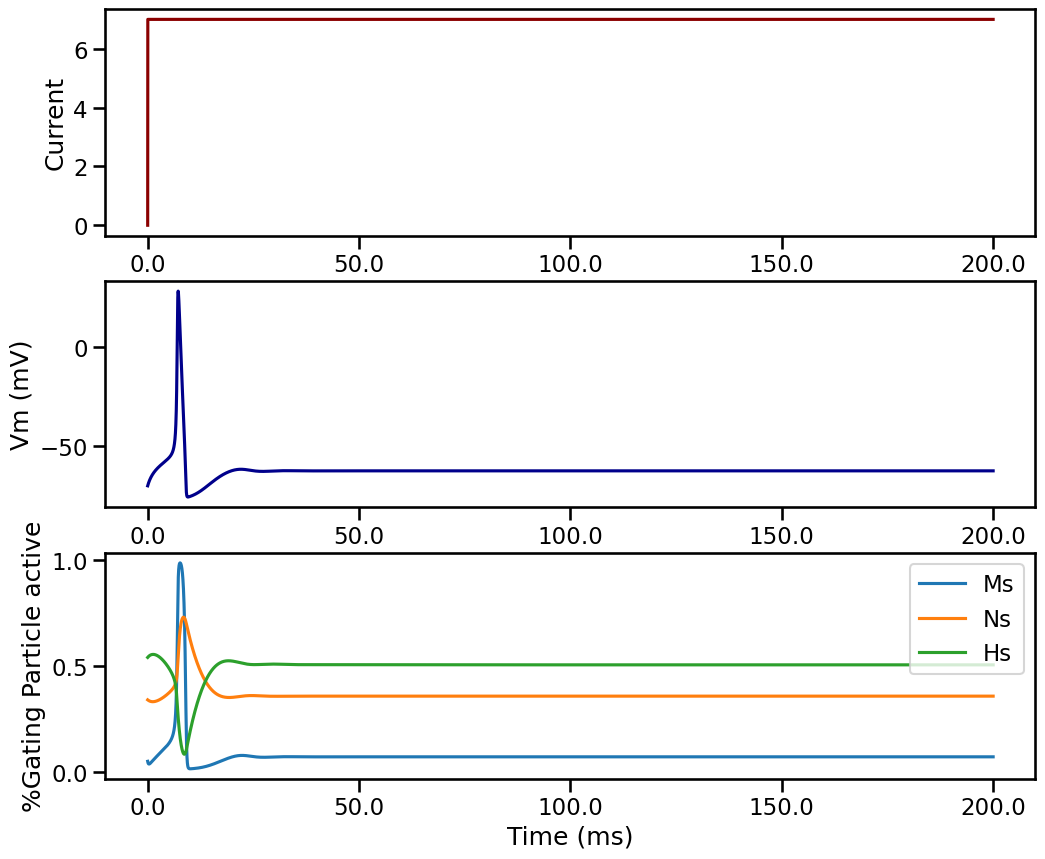

In [59]:
fig, axes = plt.subplots(3,1, figsize=(12,10))
#rescale axes labels since the model uses a timestep of 0.01
plt.setp(axes, xticks=np.linspace(0,len(Itrace),5), xticklabels=np.linspace(0,len(Itrace)*0.01,5));

axes[0].plot(Itrace,color='darkred')
axes[0].set_ylabel("Current")
axes[0].set_xlabel("Time (ms)")

axes[1].plot(V,color='darkblue')
axes[1].set_ylabel("Vm (mV)")
axes[1].set_xlabel("Time (ms)")

axes[2].plot(m)
axes[2].plot(n)
axes[2].plot(h)
axes[2].set_ylabel("%Gating Particle active")
axes[2].set_xlabel("Time (ms)")
axes[2].legend(['Ms','Ns', 'Hs'],loc='upper right')

### Question 1.1 [3]

Why is the first action potential in the plot you made bigger than the remaining action potentials? (It may be useful to modify T0 to "zoom in" and see the difference.) Make sure you specify which channel(s) would cause this & use the plots above as needed to support your answer.

>We can see why the first action potential is bigger than the remaining action potentials by considering the initial conditions of the gating variables $m,n,$ and $h$. 
> 
>At $t=0$, we have $m(0)=0.05$, corresponding to $Na^+$ activation being mostly closed; $h(0)=0.54$, corresponding to $Na^+$ inactivation being only partially relieved; and $n(0)=0.34$, indicating partial $K^+$ activation.
> Because $m$ responds rapidly to depolarization, the sodium activation quickly rises, while $h$ and $n$ change slowly. 
>Thus, during the first spike, there is a (comparatively) large sodium current ($\bar g_{Na} m^3h(V-V_{Na})$) with only small opposing potassium current ($\bar g_{K}n^4(V-V_{K}$), leading to a large depolarization. 
>
>Thereafter, the $h$ decreases and $n$ increases. 
>This means that both the sodium term weakens and the potassium term strengthens, and the remaining action potentials exhibit a lower amplitude. 

### Question 1.2 [3]
Why does the membrane become hyperpolarized soon after an action potential? Be specific as to which channel(s) & mechanisms are causing this.

> As evidenced by the above plots, after the peak of the action potential, $m$ rapidly decreases, and $h$ continues toward zero, reducing $Na^+$ channel availability so that the sodium current term $\bar g_{Na}m^3h(V-V_{Na})$ effectively vanishes. 
> We further see that the slower rate of change of $n$ keep $K^+$ channels activated, maintaining a large potassium current $\bar g_Kn^4(V-V_K)$ for a period after the peak of the potential. 
> This corresponds to rapid efflux of $K^+$ ions that outlasts the $Na^+$ influx, driving the voltage down past rest towards $V_K = -77 mV$.

### Question 1.3 [3]
Now set the potassium conductance equal to 5. This will involve modifying one of the terms in the HH function code. What do you notice about the shape of the action potentials generated? Why does this occur? What about when you set the potassium conductance to 50? (Remember to set the conductance back to its original values for subsequent questions!)

> When we set $\bar g_K = 5$, the potassium current term $\bar g_K n^4(V-V_K)$ is greatly reduced, so repolarization slows and the after-hyperpolarization is brief.
This decreases the interspike interval and therefore increases the firing rate. 
>Quantitatively, after discarding the initial transient and measuring the peak and trough of $V$, we found that $\max V = 40.9 mV$ and $\min V = -66.8 mV$. 
> Compared with the $\bar g_K =36$ baseline (with $\max V = 31.4 mv, \min V = -75.3mV$), we observe that the reduced conductance case exhibits a larger overshoot and a shallower trough, consistent with reduced $K^+$ efflux (from the reduced conductance). 
>
> In the $\bar g_K = 50$ case, the voltage trajectory exhibits a single transient spike and then settles down to a fixed value of $V \approx -62 mV$. 
This is because with the potassium conductance set so high, $K^+$ efflux is strong enough that after the initial spike the outward current remains dominant: $n$ stays elevated and $m \rightarrow 0$, meaning that the sodium current vanishes while the potassium current stays large.
> The result is that the membrane potential is clamped near a weighted average of the reversal potentials of the $K^+$ and leak currents, and no further action potential is produced. 

## Section 2: Current Step [10]
In this section, you will simulate and plot an injected current pulse.


In [86]:
#Start by setting the current at 0
Ibase = -10        
T0 = 200                  
Iinj = 0                
Istart = 50               
Iend = 150     

#Now, we'll work with the extra inputs to HH to model a step current injection
V, m, h, n, t, Itrace, alpha_m, beta_m, alpha_h, beta_h, alpha_n, beta_n = HH(Ibase, T0, InjCurrent=True, Iinj=Iinj, Istart=Istart, Iend=Iend)

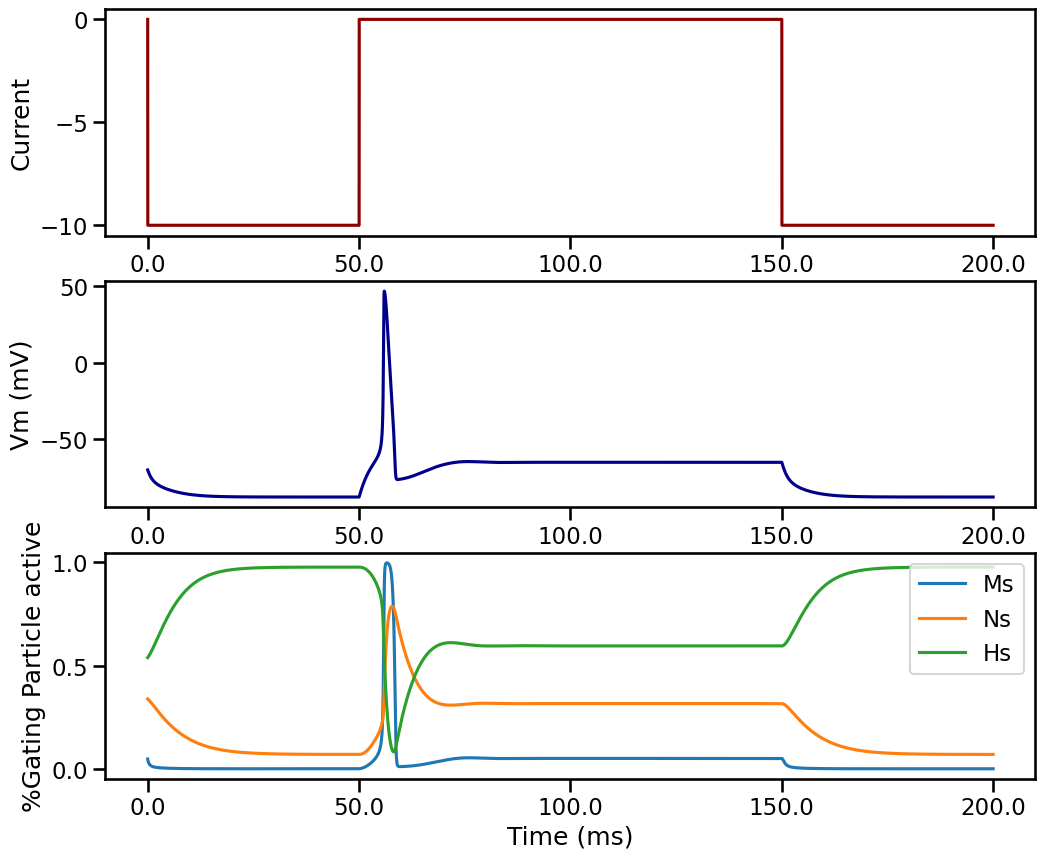

In [87]:
fig, axes = plt.subplots(3,1, figsize=(12,10))
#rescale axes labels since the model uses a timestep of 0.01
plt.setp(axes, xticks=np.linspace(0,len(Itrace),5), xticklabels=np.linspace(0,len(Itrace)*0.01,5));

axes[0].plot(Itrace,color='darkred')
axes[0].set_ylabel("Current")
axes[0].set_xlabel("Time (ms)")

axes[1].plot(V,color='darkblue')
axes[1].set_ylabel("Vm (mV)")
axes[1].set_xlabel("Time (ms)")

axes[2].plot(m)
axes[2].plot(n)
axes[2].plot(h)
axes[2].set_ylabel("%Gating Particle active")
axes[2].set_xlabel("Time (ms)")
axes[2].legend(['Ms','Ns', 'Hs'],loc='upper right')

### Question 2.1 [4]
Set $Ibase = -10 \mu A / cm^2$ and $Iinj = 0 \mu A / cm^2$ (for $50ms$ to $150ms$). You should observe an action potential generated when the current is increased to 0. Why does this occur after the cell is released from inhibition, but not when the current is initially set to 0?

> When $I_{base}=-10$, the membrane is hyperpolarized, removing $Na^+$ inactivation (corresponding to increased $h$) and deactivates $K^+$ channels (corresponding to decreased $n$).
> When the cell is then released from inhibition, there is a high influx of $Na^+$ (from rapidly increasing $m$) with little opposing $K^+$ efflux.
> This depolarizes the cell sufficiently to trigger an action potential. 
>
> When the cell is initially held at $I=0$, the gates sit near their resting values. 
> The net current at rest balances, so there is no depolarizing drive to increase $m$. 
> Consequently, sodium influx never overcomes potassium efflux, and the membrane never depolarizes enough to trigger a spike. 

### Question 2.2 [4]
Now set a current step stimulus $Ibase = 0$ for $t < 50ms, t > 150ms$ and $Iinj = 10 \mu A / cm^2$ for $50ms \leq t \leq 150ms$.

Set $\bar{g}_{Na}$ and $\bar{g}_{K} = 0$ (in the function code) and plot the injected current and the simulated voltage.

Explain the effect of setting of $\bar{g}_{Na}$ and $\bar{g}_{K}$ to zero. (1) Is the voltage transient you see due to active or passive electrical properties of the cell? Base your answer on your plot. Identify the major electrical properties of the cell that influence the observed voltage trace. How would changing these properties influence the voltage dynamics? Don't overthink this: your answer should be ~2-3 sentences.

> When the conductances are set to zero, the differential equations governing the membrane potential reduce to 
>$$\frac{dV}{dt} = \frac{I  - g_L(V - V_L)}{C},$$
> which shows the response is *purely passive*. 
> The only electrical properties that influence the observed voltage trace are therefore the leak reversal potential, leak conductance, and capacitance. 
It is further easy to show that the steady state solution is given by $V = V_L + \frac{I}{g_L}$, so increasing $V_L$ increases the steady state voltage, increasing $g_L$ attenuates the effect of the current, and increasing $C$ slows the rate of change of $V$.

## Section 3: HH Conceptual


### Question 3.1 [2]
What is the main distinction between Hodgkin-Huxley type models and integrate-and-fire type models? What are the advantages of each type?

> The primary difference is that HH type models explicitly model the ionic currents through voltage- and time-dependent conductances. 
> Integrate-and-fire models, on the other hand, abstract those details away: the membrane simply integrates input until a threshold is reached, triggering an action potential (modeled as a discontinuous spike in $V$).
>
> The HH model offers the advantage of explicitly modeling the biophysical mechanisms underlying the action potential and can more accurately capture the dynamics of membrane potential, but it is also computationally expensive and not tractable for modelling the interactions between a large number of neurons.
> Integrate-and-fire models, on the other hand, are computationally efficient and tractable for modelling large population of neurons, though they sacrifice biophysical detail.

### Question 3.2 [3]

The first non-H-H conductance found was an inactivating K current. How would you add this  channel type to the model? What do you think would happen to the voltage response to an injected step of current? (Hint: read [the section on the conor-stevens model from Theoretical Neuroscience by Dayan and Abbott](]https://drive.google.com/file/d/1aY7IJZtuxwr3nbd_VWUuFw2G4z3odCOx/view?usp=sharing)) Please answer in 3 sentences or less describing how each component relates to the model.

> To add this to an H-H type model, we would add a new generic current term:
>$$I_{new} = \bar g_{new}a^pb^q (V(t)-V_{new}),$$
> where $a$ is an activation gate, $b$ is an inactivation gate, the exponents $p,q$ are fit to data, and  $V_{new}$ is the reversal potential (for an inactivating $K^+$ current, you'd likely take $V_{new} = V_K$, but following Connor-Stevens, we allow this to be fit separately). 
> Under a depolarizing step, the new transient $K^+$ current should produce an outward flux that opposes $Na^+$ during the upstroke, delaying the first spike onset, narrowing spikes, and decreasing the firing rate. 